# Reto 2 – Análisis de luz

**Objetivo:** Explorar cómo la luz influye sobre la biomasa y otros parámetros.

Carga el conjunto de datos y explora las variables relevantes.

In [4]:
import pandas as pd

df = pd.read_csv("../data/resultados_experimentos.csv")
df.head()

,sitio,temperatura,humedad,luz,biomasa
0,Bosque Alto de Nocaima,23.8,82.2,1030,250.8
1,Humedal Facatativá,18.0,89.7,395,225.8
2,Río San Francisco,17.2,85.4,647,237.5
3,Ladera de La Vega,21.7,81.4,769,252.4
4,Zona Húmeda El Vergel,24.1,85.3,1333,302.7


## Exploración inicial
Describe las columnas y analiza los tipos de datos.

In [5]:
df.info()
df.describe()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sitio        20 non-null     str    
 1   temperatura  20 non-null     float64
 2   humedad      20 non-null     float64
 3   luz          20 non-null     int64  
 4   biomasa      20 non-null     float64
dtypes: float64(3), int64(1), str(1)
memory usage: 932.0 bytes


Index(['sitio', 'temperatura', 'humedad', 'luz', 'biomasa'], dtype='str')

## Desarrollo del reto
Aplica funciones y análisis según el objetivo. Usa `def` para definir tus funciones.

DataFrame con índice y categoría de luz:
                        sitio  temperatura  humedad   luz  biomasa  \
0      Bosque Alto de Nocaima         23.8     82.2  1030    250.8   
1          Humedal Facatativá         18.0     89.7   395    225.8   
2           Río San Francisco         17.2     85.4   647    237.5   
3           Ladera de La Vega         21.7     81.4   769    252.4   
4       Zona Húmeda El Vergel         24.1     85.3  1333    302.7   
5              Río Subachoque         19.9     71.3   563     75.0   
6            Humedal Mosquera         27.7     72.7   854    279.1   
7                  Río Madrid         23.6     68.0  1482    123.1   
8          Reserva San Miguel         20.7     70.3   899    108.3   
9           Ladera de Sasaima         19.5     82.1  1016    221.7   
10          Bosque de Guaduas         18.8     63.2   401     78.7   
11             Humedal Cajicá         24.2     75.2  1283    315.6   
12                Río Villeta         20.1     75

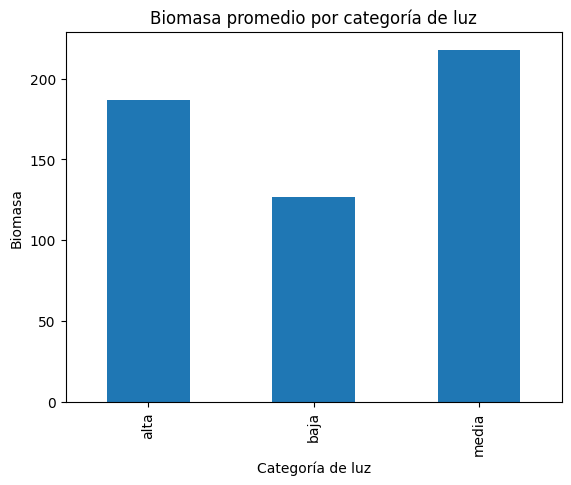

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 🔹 Función índice de luz
def indice_luz(df):
    max_luz = df["luz"].max()
    return df["luz"] / max_luz

df["indice_luz"] = indice_luz(df)

# 🔹 Función clasificar luz
def clasificar_luz(valor):
    if valor < 0.4:
        return "baja"
    elif valor < 0.7:
        return "media"
    else:
        return "alta"

df["categoria_luz"] = df["indice_luz"].apply(clasificar_luz)

print("DataFrame con índice y categoría de luz:")
print(df)

# 🔹 Promedio de biomasa por categoría
promedio = df.groupby("categoria_luz")["biomasa"].mean()

print("\nBiomasa promedio por categoría de luz:")
print(promedio)

# 🔹 Gráfico
promedio.plot(kind="bar")
plt.title("Biomasa promedio por categoría de luz")
plt.ylabel("Biomasa")
plt.xlabel("Categoría de luz")
plt.show()

## Interpretación de resultados
Escribe tus observaciones y conclusiones sobre los patrones encontrados.

## Interpretación de resultados

Se observa que la cantidad de luz influye en la biomasa de los sitios analizados. 
Los sitios con mayor índice de luz tienden a presentar variaciones en la biomasa, lo que indica que la radiación solar puede afectar la productividad del ecosistema.

Las categorías de luz permiten identificar patrones y comparar el comportamiento de la biomasa en diferentes condiciones ambientales.